In [83]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib
import os
import ast

PREDICTORS = ["PwmD", "PwmE", "sPwm", "dPwm"]   
TARGET_INT = ["Theta"]  
TARGET = ["DeltaTheta"]
     
INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = len(TARGET)   
     
TIME_STEPS = 3
TS = 0.07

In [ ]:
TITLES = ["Train_1", "Train_2", "Test_1", "Test_2", "Test_3", "Val", "LSG_1", "LSG_2"]

Datasets = []
NormDatasets = []

# Ler Datasets.xlsx
for title in TITLES:
    df = pd.read_excel("./Data/Datasets.xlsx", sheet_name=title)
    Datasets.append(df)

# Ler NormDatasets.xlsx
for title in TITLES:
    df = pd.read_excel("./Data/NormDatasets.xlsx", sheet_name=title)
    NormDatasets.append(df)
    
SCALER = joblib.load("./scalers/scaler.pkl")    
OUT_SCALER = joblib.load("./scalers/out_scaler.pkl")

In [85]:
results = pd.read_excel("resultados.xlsx")
results.head()

,model,Neurons,Ld,Lp,reg,seed,R2_Train_1_Theta,MSE_Train_1_Theta,R2_Train_2_Theta,MSE_Train_2_Theta,R2_Val_Theta,MSE_Val_Theta,R2_Test_1_Theta,MSE_Test_1_Theta,R2_Test_2_Theta,MSE_Test_2_Theta,R2_Test_3_Theta,MSE_Test_3_Theta
0,model_arch16_r0.01_seed6590,[16],0.3,0.7,0.01,6590,0.800282,0.045453,0.548565,0.103057,-0.463355,0.477685,0.485357,0.117894,0.864225,0.032196,0.695321,0.099940
1,model_arch16_r0.01_seed1209,[16],0.3,0.7,0.01,1209,0.738459,0.059523,0.555791,0.101407,-3.587775,1.497595,0.218239,0.179085,0.855006,0.034382,0.663036,0.110530
2,model_arch16_r0.01_seed2894,[16],0.3,0.7,0.01,2894,0.818230,0.041368,0.718677,0.064222,0.756950,0.079339,0.673545,0.074784,0.812805,0.044389,0.747762,0.082738
3,model_arch16_r0.01_seed4968,[16],0.3,0.7,0.01,4968,0.841458,0.036082,0.739089,0.059563,0.588464,0.134338,0.804585,0.044766,0.829518,0.040426,0.451841,0.179805
4,model_arch16_r0.01_seed7530,[16],0.3,0.7,0.01,7530,0.757491,0.055191,0.585212,0.094691,-2.526362,1.151116,0.339303,0.151352,0.862801,0.032534,0.705875,0.096478


In [86]:
def PickModels(df, target, tr1=0.0, tr2=0.0, v1=0.0, t3=0.0):

    r2_tr1 = f"R2_Train_1_{target}"
    r2_tr2 = f"R2_Train_2_{target}"
    r2_val = f"R2_Val_{target}"
    r2_t3 = f"R2_Test_3_{target}"

    # filtro mínimo
    filtered = df[
        (df[r2_tr1] > tr1) &
        (df[r2_tr2] > tr2) &
        (df[r2_t3] > t3) &
        (df[r2_val] > v1)
    ]

    if filtered.empty:
        print("Nenhum modelo satisfaz os critérios.")
        return None

    # 🔹 melhor para cada métrica
    best_tr1 = filtered.sort_values(r2_tr1, ascending=False).iloc[0]
    best_tr2 = filtered.sort_values(r2_tr2, ascending=False).iloc[0]
    best_val = filtered.sort_values(r2_val, ascending=False).iloc[0]
    best_t3 = filtered.sort_values(r2_t3, ascending=False).iloc[0]

    selected = pd.DataFrame([best_tr1, best_tr2, best_val, best_t3]).drop_duplicates()

    cols = ["model", "Neurons", "reg",  r2_tr1, r2_tr2, r2_val, r2_t3]

    table = selected[cols].copy()

    # 🔹 calcular média das métricas
    mean_values = table[[r2_tr1, r2_tr2, r2_val, r2_t3]].mean()

    mean_row = pd.DataFrame([{
        "model": "MEAN",
        "Neurons": "-",
        "reg": "-",
        r2_tr1: mean_values[r2_tr1],
        r2_tr2: mean_values[r2_tr2],
        r2_val: mean_values[r2_val],
        r2_t3: mean_values[r2_t3]
    }])

    table_mean = pd.concat([table, mean_row], ignore_index=True)

    display(table_mean)

    return selected

In [87]:
def BuildModel(architecture, r):

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(TIME_STEPS, INPUT_SIZE)))
    regularizer =  tf.keras.regularizers.l2(r)
        
    for i, units in enumerate(architecture):

        if i < len(architecture) - 1:
            model.add(
                tf.keras.layers.SimpleRNN(
                    units,
                    activation="tanh",
                    return_sequences=True,
                    kernel_regularizer=regularizer,
                    recurrent_regularizer=regularizer,
                    bias_regularizer=regularizer
            ))
        else:
            model.add(
                tf.keras.layers.SimpleRNN(
                    units,
                    activation="tanh",
                    kernel_regularizer=regularizer,
                    recurrent_regularizer=regularizer,
                    bias_regularizer=regularizer
                )
            )

    model.add(tf.keras.layers.Dense(OUTPUT_SIZE,
                                    activation='linear',
                                    kernel_regularizer=regularizer,
                                    bias_regularizer=regularizer))

    return model

In [88]:
# def LoadModelFromRow(row):

#     # arquitetura
#     arch = row["Neurons"]
#     if isinstance(arch, str):
#         arch = ast.literal_eval(arch)

#     r = float(row["reg"])
#     model_name = row["model"]

#     weights_path = f"weights/{model_name}.weights.h5"

#     # build
#     model = BuildModel(arch, r)
#     model.build((None, TIME_STEPS, INPUT_SIZE))

#     # load pesos
#     model.load_weights(weights_path)

#     return model

In [115]:
def LoadModelFromRow(row):

    model_name = row["model"]

    model_path = f"models/{model_name}.keras"
    model = tf.keras.saving.load_model(model_path)

    return model

In [116]:
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i-timesteps:i].values)
        Y_seq.append(target_data.iloc[i])
    return np.array(X_seq), np.array(Y_seq)


In [117]:
R = tf.constant(0.0341, dtype=tf.float32)
L = tf.constant(0.0606, dtype=tf.float32)
dt = tf.constant(TS, dtype=tf.float32)

def CinematicModel(Wd, We, theta):

    dtheta_cin = (R / (2 * L)) * (Wd - We)
    # dx_cin = (R / 2) * tf.cos(theta) * (Wd + We)
    # dy_cin = (R / 2) * tf.sin(theta) * (Wd + We)

    # return [dtheta_cin, dx_cin, dy_cin]
    return [dtheta_cin]


def NumericalIntegration(dataset, dq):

    q = [None] * OUTPUT_SIZE

    init_vals = np.array([
        dataset[name].iloc[0] for name in TARGET_INT
    ])

    for j in range(OUTPUT_SIZE):
        q[j] = init_vals[j] + np.cumsum(dq[j] * TS)

    return q

def GetCin(dataset): 
    dq = CinematicModel(tf.convert_to_tensor(dataset["Wd"].values, dtype=tf.float32),
                        tf.convert_to_tensor(dataset["We"].values, dtype=tf.float32), 
                        tf.convert_to_tensor(dataset["Theta"].values, dtype=tf.float32))
    q = NumericalIntegration(dataset, dq)
    return np.vstack(q).T, np.vstack(dq).T

In [ ]:
def PlotOut(ax, title, target_name, y_true, y_pred, y_cin):
    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    ax.plot(time, y_true, linestyle='-', linewidth=1.5, label='Amostras Reais')
    ax.plot(time, y_pred, linestyle='--', linewidth=1.5, label='Valores preditos')
    ax.plot(time, y_cin, linestyle=':', linewidth=0.5, label='Modelo Cinemático')

    ax.set_title(f'{title} - {target_name}')
    ax.set_xlabel('Tempo [s]')
    ax.set_ylabel(target_name)
    ax.legend()
    ax.grid(True)


def EvalModel(model):
    n_datasets = len(Datasets)
    n_targets = len(TARGET)

    fig, axs = plt.subplots(
        n_datasets,
        2 * n_targets,
        figsize=(6 * 2 * n_targets, 4 * n_datasets)
    )

    metrics = {
        name: {
            "R2_Train_1": [], "R2_Train_2": [],
            "R2_Val": [],
            "R2_Test_1": [], "R2_Test_2": [], "R2_Test_3": [],
            "R2_LSG_1": [], "R2_LSG_2": [],
            "MSE_Train_1": [], "MSE_Train_2": [],
            "MSE_Val": [],
            "MSE_Test_1": [], "MSE_Test_2": [], "MSE_Test_3": [],
            "MSE_LSG_1": [], "MSE_LSG_2": [],
        }
        for name in TARGET_INT
    }

    for i, NormDataset in enumerate(NormDatasets):

        x = NormDataset[PREDICTORS]
        y = Datasets[i][TARGET_INT]
        dy = Datasets[i][TARGET]

        x, y = CreateSequences(x, y, TIME_STEPS)

        # predição (dy normalizado)
        dy_pred = model(tf.convert_to_tensor(x, dtype=tf.float32)).numpy()

        # desnormalizar
        dy_pred = OUT_SCALER.inverse_transform(dy_pred)

        # cinemático
        y_cin, dy_cin = GetCin(Datasets[i])

        # alinhar tamanhos
        y_true = y
        dy_true = dy.iloc[TIME_STEPS:].values

        y_cin = y_cin[:y_true.shape[0]]
        dy_cin = dy_cin[:dy_true.shape[0]]

        # reconstrução de y
        y_pred = np.zeros_like(dy_pred)

        init_vals = np.array([
            Datasets[i][name].iloc[0] for name in TARGET_INT
        ])

        for j in range(n_targets):
            y_pred[:, j] = init_vals[j] + np.cumsum(dy_pred[:, j] * TS)

        # =========================
        # MÉTRICAS + PLOTS
        # =========================
        for j, name in enumerate(TARGET_INT):

            # métricas (posição)
            r2 = r2_score(y_true[:, j], y_pred[:, j])
            mse = mean_squared_error(y_true[:, j], y_pred[:, j])

            metrics[name][f"R2_{TITLES[i]}"].append(r2)
            metrics[name][f"MSE_{TITLES[i]}"].append(mse)

            print(f"{name} | {TITLES[i]} -> R² = {r2:.4f}, MSE = {mse:.4e}")

            # 🔹 coluna da posição (y)
            ax_y = axs[i, j] if n_datasets > 1 else axs[j]
            PlotOut(
                ax_y,
                TITLES[i],
                f"{name}",
                y_true[:, j],
                y_pred[:, j],
                y_cin[:, j]
            )

            # 🔹 coluna da derivada (dy)
            ax_dy = axs[i, j + n_targets] if n_datasets > 1 else axs[j + n_targets]
            PlotOut(
                ax_dy,
                TITLES[i],
                f"d{name}",
                dy_true[:, j],
                dy_pred[:, j],
                dy_cin[:, j]
            )

    plt.tight_layout()
    return metrics

In [122]:
rows = PickModels(results, "Theta", tr1=0, tr2=0, v1=0.5, t3=0.5)

,model,Neurons,reg,R2_Train_1_Theta,R2_Train_2_Theta,R2_Val_Theta,R2_Test_3_Theta
0,model_arch8-4_r0.01_seed1209,"[8, 4]",0.01,0.947753,0.754217,0.844499,0.672893
1,model_arch32_r0.9_seed7530,[32],0.9,0.820765,0.718569,0.573932,0.761352
2,MEAN,-,-,0.884259,0.736393,0.709215,0.717122


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 3, 8)              104       
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 4)                 52        
                                                                 
 dense (Dense)               (None, 1)                 5         
                                                                 
Total params: 161 (644.00 Byte)
Trainable params: 161 (644.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Theta | Train_1 -> R² = -23.9732, MSE = 5.6835e+00
Theta | Train_2 -> R² = -4.7901, MSE = 1.3218e+00
Theta | Test_1 -> R² = -43.5732, MSE = 1.0211e+01
Theta | Test_2 -> R² = -17.8851, MSE = 4.4782e+00
Theta | Test_3 -> R² = -40.2258, MSE = 1.3523e+01
Theta | Val -> R² = -200.5401, 

model                model_arch8-4_r0.01_seed1209
Neurons                                    [8, 4]
Ld                                            0.3
Lp                                            0.7
reg                                          0.01
seed                                         1209
R2_Train_1_Theta                         0.947753
MSE_Train_1_Theta                        0.011891
R2_Train_2_Theta                         0.754217
MSE_Train_2_Theta                        0.056109
R2_Val_Theta                             0.844499
MSE_Val_Theta                             0.05076
R2_Test_1_Theta                          0.924105
MSE_Test_1_Theta                         0.017386
R2_Test_2_Theta                          0.851388
MSE_Test_2_Theta                          0.03524
R2_Test_3_Theta                          0.672893
MSE_Test_3_Theta                         0.107297
Name: 101, dtype: object

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 32)                1184      
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 1217 (4.75 KB)
Trainable params: 1217 (4.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Theta | Train_1 -> R² = -21.8150, MSE = 5.1923e+00
Theta | Train_2 -> R² = -5.2951, MSE = 1.4371e+00
Theta | Test_1 -> R² = -36.3725, MSE = 8.5613e+00
Theta | Test_2 -> R² = -14.3139, MSE = 3.6314e+00
Theta | Test_3 -> R² = -89.4240, MSE = 2.9661e+01
Theta | Val -> R² = -314.3050, MSE = 1.0293e+02
Theta | LSG_1 -> R² = -153.7976, MSE = 6.4621e+01
Theta | LSG_2 -> R² = -324.9871, MSE = 1.1410e+02


model                model_arch32_r0.9_seed7530
Neurons                                    [32]
Ld                                          0.3
Lp                                          0.7
reg                                         0.9
seed                                       7530
R2_Train_1_Theta                       0.820765
MSE_Train_1_Theta                      0.040791
R2_Train_2_Theta                       0.718569
MSE_Train_2_Theta                      0.064247
R2_Val_Theta                           0.573932
MSE_Val_Theta                          0.139082
R2_Test_1_Theta                        0.621145
MSE_Test_1_Theta                       0.086788
R2_Test_2_Theta                        0.858647
MSE_Test_2_Theta                       0.033519
R2_Test_3_Theta                        0.761352
MSE_Test_3_Theta                       0.078281
Name: 29, dtype: object

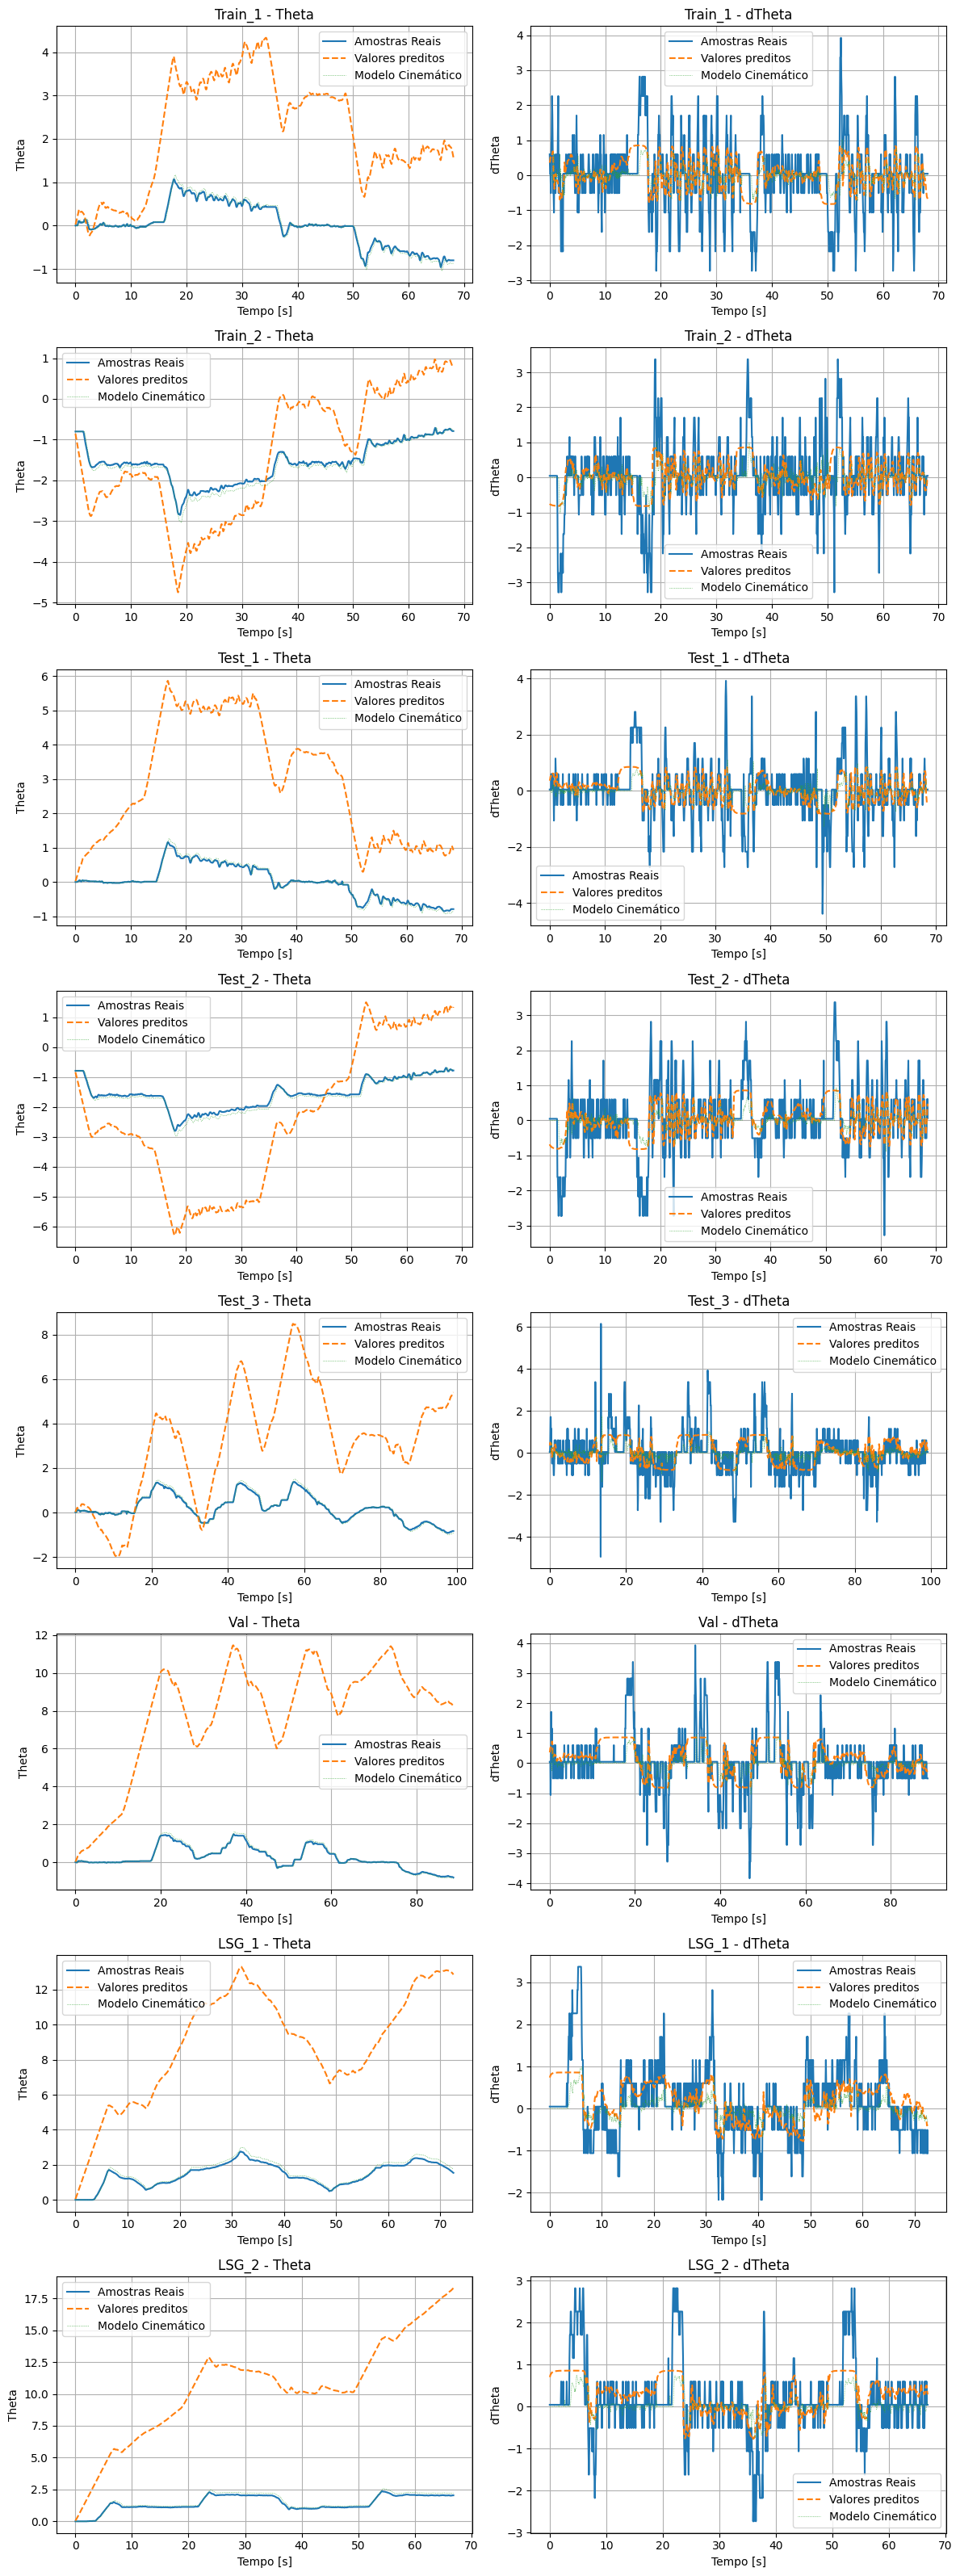

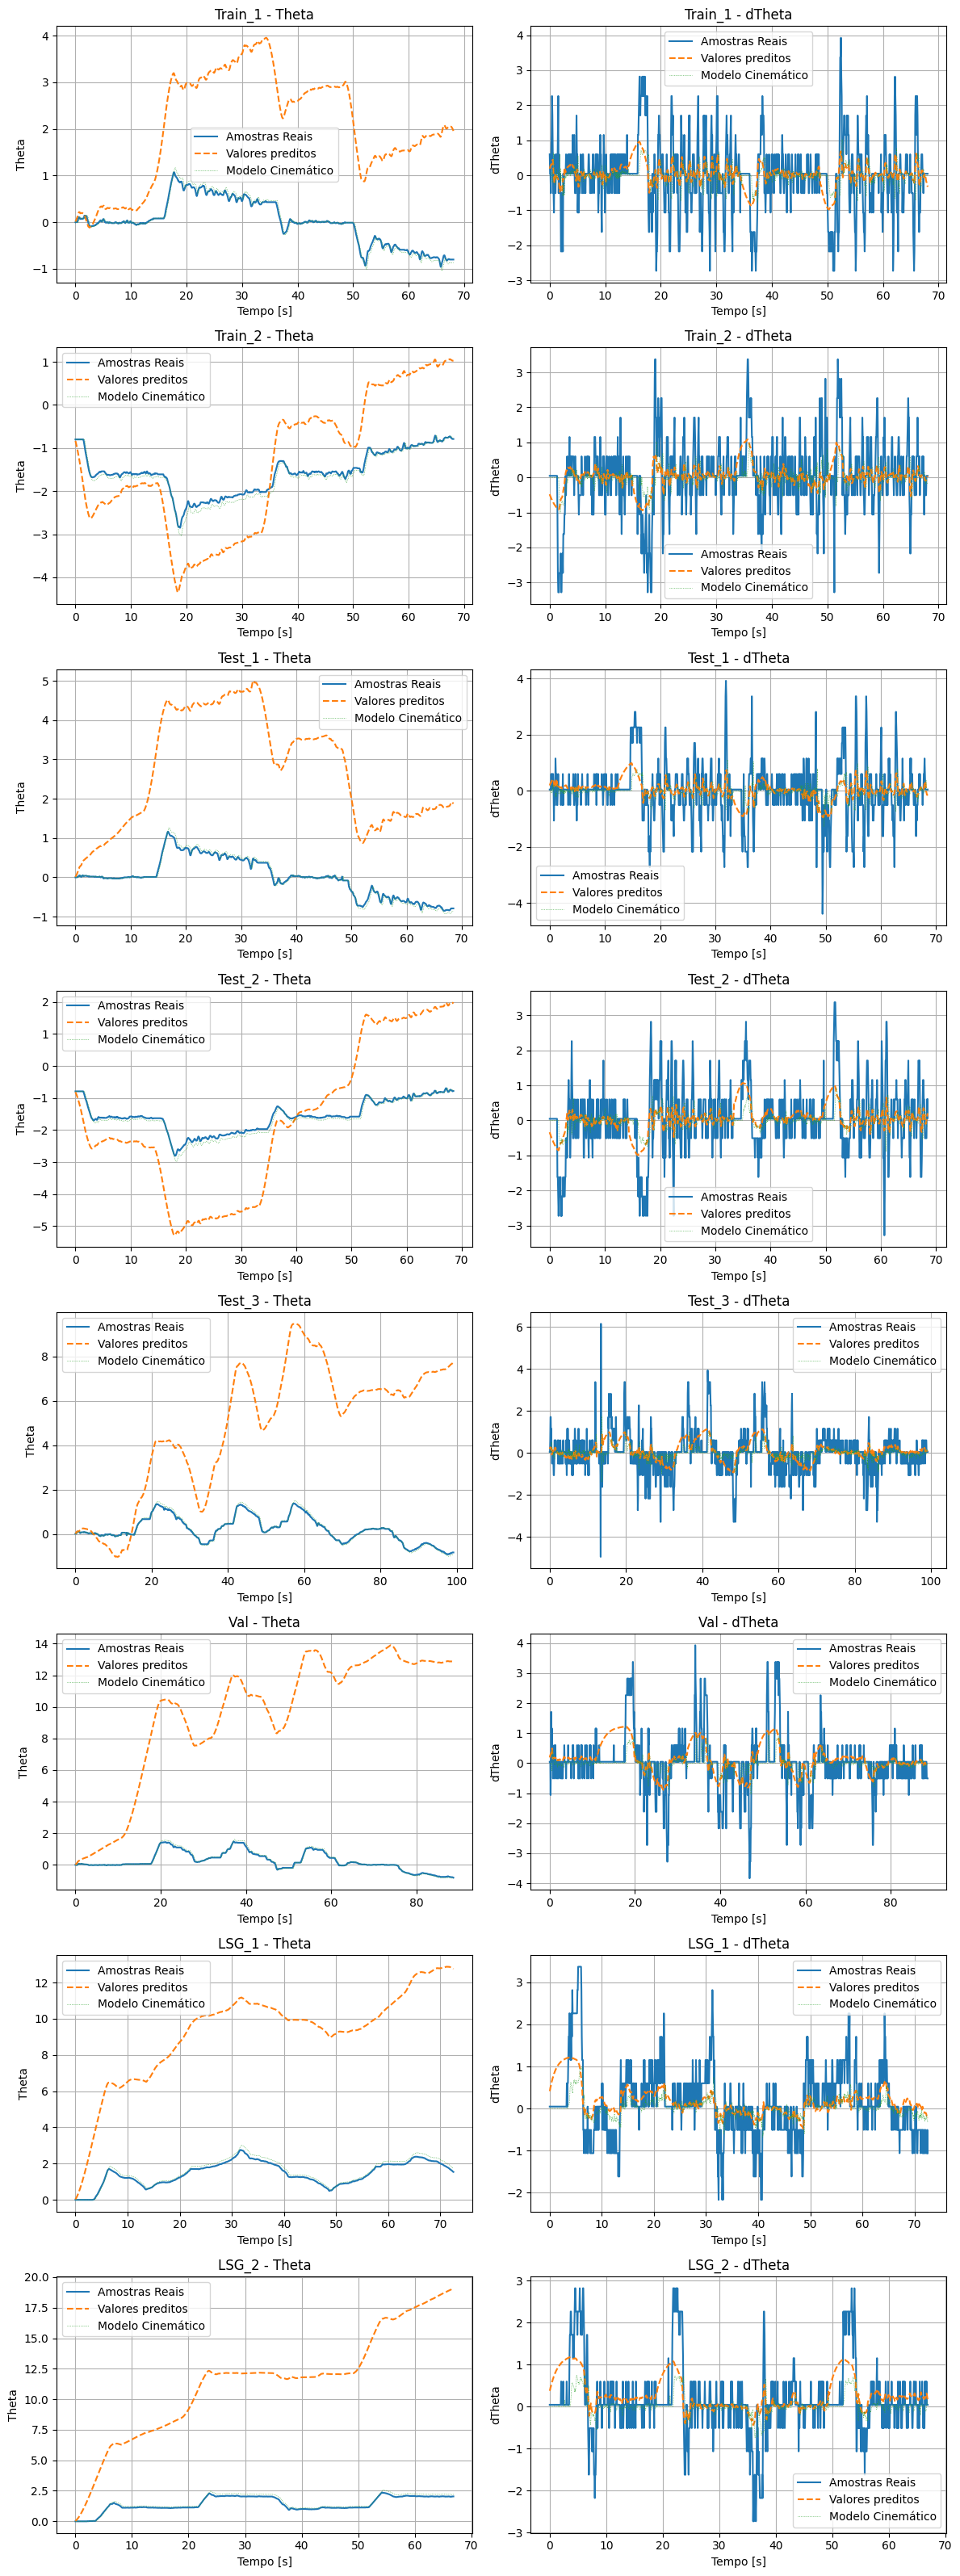

In [125]:
for i in range(len(rows)):
    row = rows.iloc[i]
    model = LoadModelFromRow(row)
    model.summary()
    metrics = EvalModel(model)
    display(row)